# 🧪 RAG Benchmark — Modelos GGUF locales

Notebook de prueba que reemplaza la llamada a la API de OpenAI por modelos GGUF locales  
sin modificar la estructura del RAG existente.

**Modelos disponibles:**
| Alias | Archivo GGUF | HuggingFace |
|-------|--------------|-------------|
| `qwen3-4b` | `Qwen3-4B-Q4_K_M.gguf` | [Qwen/Qwen3-4B-GGUF](https://huggingface.co/Qwen/Qwen3-4B-GGUF) |
| `gemma-4-e2b` | `gemma-4-E2B-it-Q4_K_M.gguf` | [unsloth/gemma-4-E2B-it-GGUF](https://huggingface.co/unsloth/gemma-4-E2B-it-GGUF) |
| `qwen3-1.7b` | `Qwen3-1.7B-Q4_K_M.gguf` | [unsloth/Qwen3-1.7B-GGUF](https://huggingface.co/unsloth/Qwen3-1.7B-GGUF) |

> **Solo se modifica `generar_respuesta`** — el resto del pipeline RAG (Milvus, embeddings, caché, prompt) permanece intacto.

## 0 · Localizar el proyecto

In [21]:
import sys
from pathlib import Path

# Busca la raíz del proyecto mediante un archivo que sí existe en este repositorio.
CANDIDATES = [Path.cwd(), Path.cwd().parent]
ROOT = None

for candidate in CANDIDATES:
    probe = candidate
    while probe != probe.parent and not (probe / "pyproject.toml").exists():
        probe = probe.parent
    if (probe / "pyproject.toml").exists():
        ROOT = probe
        break

if ROOT is None:
    raise RuntimeError(
        "No se encontró la raíz del proyecto (busca pyproject.toml).\n"
        "Abre el notebook dentro de este repositorio."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"✅ Proyecto en: {ROOT}")

✅ Proyecto en: /Users/anpalopg/Desktop/PROMETEO/pmai-model-vision-language


## 1 · Verificar llama-cpp-python

In [22]:
try:
    from llama_cpp import Llama
    print(f"✅ llama-cpp-python disponible ({Llama.__name__})")
except ImportError:
    print("⚠️  llama-cpp-python no encontrado. Instalando desde PyPI...")
    # PyPI compila la librería localmente y evita la rueda CPU corrupta.
    %pip install --no-cache-dir --index-url https://pypi.org/simple llama-cpp-python
    from llama_cpp import Llama
    print(f"✅ llama-cpp-python instalado correctamente ({Llama.__name__})")

✅ llama-cpp-python disponible (Llama)


## 2 · Configuración GGUF (ajusta rutas y parámetros)

In [23]:
# ─────────────────────────────────────────────────
#  Directorio donde guardas los archivos .gguf
#  Cambia GGUF_DIR si los tienes en otra ruta
# ─────────────────────────────────────────────────
GGUF_DIR = ROOT / "models" / "gguf"
GGUF_DIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────
#  Configuración compartida para los 3 modelos
# ─────────────────────────────────────────────────
CONFIG = {
    "ctx_size"    : 2048,
    "n_threads"   : 4,      # Ajustar según Jetson / CPU disponible
    "n_gpu_layers": 10,     # 0 = solo CPU; aumentar si hay VRAM
    "temperature" : 0.7,
    "top_p"       : 0.9,
    "top_k"       : 40,
}

# ─────────────────────────────────────────────────
#  Registro de modelos disponibles
# ─────────────────────────────────────────────────
MODELOS = {
    "qwen3-4b": {
        "archivo"    : GGUF_DIR / "Qwen3-4B-Q4_K_M.gguf",
        "descripcion": "Qwen3-4B Q4_K_M (~2.5 GB)",
        "hf_url"     : "https://huggingface.co/Qwen/Qwen3-4B-GGUF",
        "hf_repo"    : "Qwen/Qwen3-4B-GGUF",
        "hf_file"    : "Qwen3-4B-Q4_K_M.gguf",
    },
    "gemma-4-e2b": {
        "archivo"    : GGUF_DIR / "gemma-4-E2B-it-Q4_K_M.gguf",
        "descripcion": "Gemma-4 E2B Instruct Q4_K_M (~1.5 GB)",
        "hf_url"     : "https://huggingface.co/unsloth/gemma-4-E2B-it-GGUF",
        "hf_repo"    : "unsloth/gemma-4-E2B-it-GGUF",
        "hf_file"    : "gemma-4-E2B-it-Q4_K_M.gguf",
    },
    "qwen3-1.7b": {
        "archivo"    : GGUF_DIR / "Qwen3-1.7B-Q4_K_M.gguf",
        "descripcion": "Qwen3-1.7B Q4_K_M (~1.1 GB)",
        "hf_url"     : "https://huggingface.co/unsloth/Qwen3-1.7B-GGUF",
        "hf_repo"    : "unsloth/Qwen3-1.7B-GGUF",
        "hf_file"    : "Qwen3-1.7B-Q4_K_M.gguf",
    },
}

print(f"📁 Directorio GGUF: {GGUF_DIR}")
print("\nModelos configurados:")
for alias, info in MODELOS.items():
    existe = "✅" if info["archivo"].exists() else "❌ (pendiente descarga)"
    print(f"  [{alias}]  {info['descripcion']}  {existe}")

📁 Directorio GGUF: /Users/anpalopg/Desktop/PROMETEO/pmai-model-vision-language/models/gguf

Modelos configurados:
  [qwen3-4b]  Qwen3-4B Q4_K_M (~2.5 GB)  ❌ (pendiente descarga)
  [gemma-4-e2b]  Gemma-4 E2B Instruct Q4_K_M (~1.5 GB)  ❌ (pendiente descarga)
  [qwen3-1.7b]  Qwen3-1.7B Q4_K_M (~1.1 GB)  ✅


## 3 · Descarga automática desde HuggingFace (opcional)

Ejecuta esta celda solo si necesitas descargar los modelos.  
Requiere `huggingface_hub` (`pip install huggingface_hub`).

In [24]:
# ─────────────────────────────────────────────────
#  Cambia a True los modelos que quieras descargar
# ─────────────────────────────────────────────────
DESCARGAR = {
    "qwen3-4b"   : False,
    "gemma-4-e2b": False,
    "qwen3-1.7b" : True,
}

modelos_a_descargar = [alias for alias, descarga in DESCARGAR.items() if descarga]

if modelos_a_descargar:
    try:
        from huggingface_hub import hf_hub_download
    except ImportError:
        %pip install huggingface_hub
        from huggingface_hub import hf_hub_download

    for alias in modelos_a_descargar:
        info = MODELOS[alias]
        destino = info["archivo"]
        if destino.exists():
            print(f"⏭️  [{alias}] Ya existe, se omite: {destino.name}")
            continue
        print(f"⬇️  Descargando [{alias}] desde {info['hf_repo']} ...")
        ruta = hf_hub_download(
            repo_id   = info["hf_repo"],
            filename  = info["hf_file"],
            local_dir = str(GGUF_DIR),
        )
        print(f"✅ [{alias}] guardado en: {ruta}")
else:
    print("ℹ️  No hay modelos marcados para descargar en esta ejecución.")

⏭️  [qwen3-1.7b] Ya existe, se omite: Qwen3-1.7B-Q4_K_M.gguf


## 4 · Motor GGUF — carga y cambio de modelo en caliente

In [25]:
import json
import re
import time
import logging
from llama_cpp import Llama

logger = logging.getLogger("gguf_engine")

# ─────────────────────────────────────────────────
#  Estado global del motor: un único Llama cargado
# ─────────────────────────────────────────────────
_llm_activo: Llama | None = None
_alias_activo: str | None = None


def cargar_modelo(alias: str) -> None:
    """
    Carga el modelo indicado por `alias`.
    Si ya está cargado el mismo alias, no hace nada.
    Si había otro cargado, lo descarga primero (libera RAM).
    """
    global _llm_activo, _alias_activo

    if alias not in MODELOS:
        raise ValueError(f"Alias desconocido: '{alias}'. Opciones: {list(MODELOS)}")

    if alias == _alias_activo:
        print(f"ℹ️  [{alias}] ya está cargado.")
        return

    ruta = MODELOS[alias]["archivo"]
    if not ruta.exists():
        raise FileNotFoundError(
            f"Archivo GGUF no encontrado: {ruta}\n"
            f"Descárgalo de: {MODELOS[alias]['hf_url']}"
        )

    # Descargar modelo anterior si lo hay
    if _llm_activo is not None:
        print(f"🔄 Descargando [{_alias_activo}] de memoria...")
        del _llm_activo
        _llm_activo = None
        _alias_activo = None

    print(f"⏳ Cargando [{alias}] — {MODELOS[alias]['descripcion']} ...")
    t0 = time.perf_counter()
    _llm_activo = Llama(
        model_path  = str(ruta),
        n_ctx       = CONFIG["ctx_size"],
        n_threads   = CONFIG["n_threads"],
        n_gpu_layers= CONFIG["n_gpu_layers"],
        verbose     = False,
    )
    _alias_activo = alias
    elapsed = time.perf_counter() - t0
    print(f"✅ [{alias}] cargado en {elapsed:.1f}s")


def modelo_activo() -> str | None:
    """Devuelve el alias del modelo actualmente en memoria, o None."""
    return _alias_activo


print("✅ Motor GGUF definido.")

✅ Motor GGUF definido.


## 5 · `generar_respuesta` GGUF — reemplazo de la API

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
#  Constantes de validación (copiadas de gptapi.py para mantener coherencia)
# ─────────────────────────────────────────────────────────────────────────────
MIN_MOVIMIENTO_ID = 1
MAX_MOVIMIENTO_ID = 34


def _validar_movimientos_gguf(movimientos: list) -> list:
    if not movimientos or not isinstance(movimientos, list):
        return []
    validos = []
    for mov_id in movimientos:
        try:
            id_int = int(mov_id)
            if MIN_MOVIMIENTO_ID <= id_int <= MAX_MOVIMIENTO_ID:
                validos.append(id_int)
        except (ValueError, TypeError):
            pass
    return validos


def _extraer_json(texto: str) -> dict | None:
    """
    Intenta extraer un objeto JSON del texto del modelo.
    Primero prueba decodificación directa; si falla, busca
    el primer bloque {...} con regex.
    """
    texto = texto.strip()
    try:
        return json.loads(texto)
    except json.JSONDecodeError:
        pass
    # Buscar bloque JSON dentro del texto
    match = re.search(r'\{[^{}]*"respuesta"[^{}]*\}', texto, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass
    return None


def generar_respuesta_gguf(prompt: str) -> dict:
    """
    Reemplaza `utils.gpt.gptapi.generar_respuesta` usando el modelo
    GGUF actualmente cargado. Misma firma y mismo formato de salida.

    Returns:
        {"respuesta": str, "movimientos": list[int]}
    """
    if _llm_activo is None:
        raise RuntimeError(
            "Ningún modelo GGUF cargado. Llama primero a cargar_modelo(alias)."
        )

    salida = _llm_activo(
        prompt,
        max_tokens  = 512,
        temperature = CONFIG["temperature"],
        top_p       = CONFIG["top_p"],
        top_k       = CONFIG["top_k"],
        stop        = ["\n\n\n", "<|endoftext|>", "<|im_end|>"],
    )

    texto = salida["choices"][0]["text"]
    data = _extraer_json(texto)

    if data:
        return {
            "respuesta" : data.get("respuesta", ""),
            "movimientos": _validar_movimientos_gguf(data.get("movimientos", [])),
        }
    # Fallback: respuesta en texto plano
    return {"respuesta": texto.strip(), "movimientos": []}


print("✅ generar_respuesta_gguf definida.")

✅ generar_respuesta_gguf definida.


## 6 · Inyección en el pipeline RAG (sin tocar el código fuente)

In [27]:
import importlib
import utils.config       as config
import utils.milvus.conexion as conexion
import utils.milvus.busqueda as busqueda
import utils.gpt.gptapi   as gptapi_module
import utils.main         as main_module

importlib.reload(config)
importlib.reload(conexion)
importlib.reload(busqueda)
importlib.reload(gptapi_module)
importlib.reload(main_module)

# ─────────────────────────────────────────────────────────────────────────────
#  INYECCIÓN: parchamos la función generar_respuesta dentro del módulo main
#  para que use el motor GGUF en vez de la API de OpenAI.
#  El código fuente de main.py y gptapi.py NO se modifica.
# ─────────────────────────────────────────────────────────────────────────────
main_module.generar_respuesta = generar_respuesta_gguf

from models.schemas import GlobalObjectForContext

responder        = main_module.responder
cargar_movimientos = main_module.cargar_movimientos
secuencias       = cargar_movimientos()

print("✅ Pipeline RAG listo con motor GGUF.")
print(f"   Movimientos disponibles: {len(secuencias)}")

✅ Pipeline RAG listo con motor GGUF.
   Movimientos disponibles: 34


## 7 · Selector de modelo activo

Ejecuta esta celda cada vez que quieras cambiar de modelo —  
**no necesitas reiniciar el kernel**.

In [28]:
# ─────────────────────────────────────────────────
#  ✏️  Cambia este valor para seleccionar el modelo:
#      "qwen3-4b"   | "gemma-4-e2b"  | "qwen3-1.7b"
# ─────────────────────────────────────────────────
MODELO_SELECCIONADO = "qwen3-1.7b"

cargar_modelo(MODELO_SELECCIONADO)
print(f"\n🟢 Modelo activo: {modelo_activo()}")

⏳ Cargando [qwen3-1.7b] — Qwen3-1.7B Q4_K_M (~1.1 GB) ...
✅ [qwen3-1.7b] cargado en 0.4s

🟢 Modelo activo: qwen3-1.7b


## 8 · Consulta individual

In [29]:
import time

obj = GlobalObjectForContext(
    id_global = "test-1",
    etiqueta  = "Usuario de prueba",
    confianza = 0.80,
    contexto  = "Persona frente a la cámara",
    question  = "¿Cuáles son los departamentos de la Universidad Libre?",
)

t0       = time.perf_counter()
resultado = responder(obj, secuencias)
latencia  = time.perf_counter() - t0

print(f"Modelo  : {modelo_activo()}")
print(f"Fuente  : {resultado['fuente']}")
print(f"Latencia: {latencia:.2f}s")
print(f"Movim.  : {resultado['movimiento']}")
print(f"\nRespuesta:\n{resultado['respuesta']}")

Modelo  : qwen3-1.7b
Fuente  : cache
Latencia: 0.16s
Movim.  : 5

Respuesta:
La Universidad Libre es una destacada institución de educación superior en Colombia, fundada en 1923. Se caracteriza por su enfoque en la formación integral de sus estudiantes, promoviendo valores como la libertad, la justicia y la responsabilidad social. La universidad ofrece diversas carreras y programas de posgrado, y tiene un fuerte compromiso con la investigación y el desarrollo de la comunidad. Si deseas saber más sobre algún aspecto específico, estaré encantado de ayudarte.


## 9 · Suite de preguntas de benchmark

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
#  Batería de preguntas representativas del sistema RAG
# ─────────────────────────────────────────────────────────────────────────────
PREGUNTAS_BENCHMARK = [
    # Saludos / sociales
    {"pregunta": "Hola R-One",             "tipo": "saludo"},
    {"pregunta": "¿Quién eres tú?",        "tipo": "identidad"},
    # Conocimiento universidad
    {"pregunta": "¿Qué es la Universidad Libre?",              "tipo": "conocimiento"},
    {"pregunta": "¿Cuáles son los departamentos de la Universidad Libre?", "tipo": "dato_especifico"},
    {"pregunta": "¿Qué es el semillero Prometeo?",             "tipo": "conocimiento"},
    # Datos específicos
    {"pregunta": "¿Cuál es el horario de la biblioteca?",      "tipo": "dato_especifico"},
    {"pregunta": "¿Cuántas facultades tiene la universidad?",  "tipo": "dato_especifico"},
    # Sin información
    {"pregunta": "¿Cuántos estudiantes hay hoy en el campus?", "tipo": "sin_datos"},
    # Afectiva
    {"pregunta": "¿Puedes ser mi amigo?",                      "tipo": "afectiva"},
]

print(f"Suite lista: {len(PREGUNTAS_BENCHMARK)} preguntas")

Suite lista: 9 preguntas


## 10 · Ejecutar benchmark para el modelo activo

In [32]:
import statistics


def ejecutar_benchmark(alias: str) -> list[dict]:
    """
    Carga `alias`, ejecuta todas las preguntas de la suite
    y devuelve una lista de resultados.
    """
    cargar_modelo(alias)
    resultados = []

    for item in PREGUNTAS_BENCHMARK:
        obj = GlobalObjectForContext(
            id_global = "bench",
            etiqueta  = "Evaluador",
            confianza = 0.99,
            contexto  = "Entorno de prueba",
            question  = item["pregunta"],
        )
        t0        = time.perf_counter()
        resultado = responder(obj, secuencias)
        latencia  = time.perf_counter() - t0

        resultados.append({
            "modelo"   : alias,
            "tipo"     : item["tipo"],
            "pregunta" : item["pregunta"],
            "respuesta": resultado["respuesta"],
            "movimiento": resultado["movimiento"],
            "fuente"   : resultado["fuente"],
            "latencia_s": round(latencia, 3),
        })
        estado = "🟡 cache" if resultado["fuente"] == "cache" else "🟢 llm"
        print(f"  {estado}  [{latencia:.2f}s]  {item['pregunta'][:60]}")

    return resultados


# Ejecutar para el modelo actualmente seleccionado
print(f"\n▶  Benchmark: {modelo_activo()}\n")
resultados_actuales = ejecutar_benchmark(modelo_activo())

latencias = [r["latencia_s"] for r in resultados_actuales if r["fuente"] == "llm"]
if latencias:
    print(f"\n── LLM latency ──")
    print(f"  min   : {min(latencias):.2f}s")
    print(f"  max   : {max(latencias):.2f}s")
    print(f"  media : {statistics.mean(latencias):.2f}s")
    print(f"  mediana: {statistics.median(latencias):.2f}s")


▶  Benchmark: qwen3-1.7b

ℹ️  [qwen3-1.7b] ya está cargado.
  🟢 llm  [8.92s]  Hola R-One
  🟢 llm  [7.84s]  ¿Quién eres tú?
  🟡 cache  [0.04s]  ¿Qué es la Universidad Libre?
  🟡 cache  [0.02s]  ¿Cuáles son los departamentos de la Universidad Libre?
  🟢 llm  [7.83s]  ¿Qué es el semillero Prometeo?
  🟡 cache  [0.05s]  ¿Cuál es el horario de la biblioteca?
  🟡 cache  [0.02s]  ¿Cuántas facultades tiene la universidad?
  🟢 llm  [7.77s]  ¿Cuántos estudiantes hay hoy en el campus?
  🟢 llm  [7.98s]  ¿Puedes ser mi amigo?

── LLM latency ──
  min   : 7.77s
  max   : 8.92s
  media : 8.07s
  mediana: 7.84s


## 11 · Comparativa entre los 3 modelos

> Esta celda descarga y carga los 3 modelos secuencialmente.  
> Requiere que los 3 archivos GGUF estén disponibles.

In [33]:
todos_resultados = []

for alias in MODELOS:
    if not MODELOS[alias]["archivo"].exists():
        print(f"⚠️  [{alias}] no encontrado — se omite.")
        continue
    print(f"\n{'='*60}")
    print(f"  Evaluando: {alias}")
    print(f"{'='*60}")
    resultados = ejecutar_benchmark(alias)
    todos_resultados.extend(resultados)

print("\n✅ Comparativa completa.")

⚠️  [qwen3-4b] no encontrado — se omite.
⚠️  [gemma-4-e2b] no encontrado — se omite.

  Evaluando: qwen3-1.7b
ℹ️  [qwen3-1.7b] ya está cargado.
  🟡 cache  [0.09s]  Hola R-One
  🟡 cache  [0.05s]  ¿Quién eres tú?
  🟡 cache  [0.02s]  ¿Qué es la Universidad Libre?
  🟡 cache  [0.02s]  ¿Cuáles son los departamentos de la Universidad Libre?
  🟡 cache  [0.05s]  ¿Qué es el semillero Prometeo?
  🟡 cache  [0.04s]  ¿Cuál es el horario de la biblioteca?
  🟡 cache  [0.02s]  ¿Cuántas facultades tiene la universidad?
  🟡 cache  [0.05s]  ¿Cuántos estudiantes hay hoy en el campus?
  🟡 cache  [0.05s]  ¿Puedes ser mi amigo?

✅ Comparativa completa.


## 12 · Tabla de resultados

In [34]:
import pandas as pd

df = pd.DataFrame(todos_resultados)

# Tabla resumen por modelo
resumen = (
    df[df["fuente"] == "llm"]
    .groupby("modelo")["latencia_s"]
    .agg(n_llm="count", lat_min="min", lat_max="max", lat_media="mean", lat_mediana="median")
    .round(3)
    .reset_index()
)
cache_counts = df[df["fuente"] == "cache"].groupby("modelo").size().rename("n_cache")
resumen = resumen.merge(cache_counts, on="modelo", how="left").fillna(0)
resumen["n_cache"] = resumen["n_cache"].astype(int)

print("\n📊 Resumen por modelo:")
print(resumen.to_string(index=False))

print("\n📋 Resultados completos:")
pd.set_option("display.max_colwidth", 80)
df[["modelo", "tipo", "pregunta", "fuente", "latencia_s", "movimiento"]]


📊 Resumen por modelo:
Empty DataFrame
Columns: [modelo, n_llm, lat_min, lat_max, lat_media, lat_mediana, n_cache]
Index: []

📋 Resultados completos:


,modelo,tipo,pregunta,fuente,latencia_s,movimiento
0,qwen3-1.7b,saludo,Hola R-One,cache,0.091,14
1,qwen3-1.7b,identidad,¿Quién eres tú?,cache,0.051,1
2,qwen3-1.7b,conocimiento,¿Qué es la Universidad Libre?,cache,0.017,5
3,qwen3-1.7b,dato_especifico,¿Cuáles son los departamentos de la Universidad Libre?,cache,0.020,5
4,qwen3-1.7b,conocimiento,¿Qué es el semillero Prometeo?,cache,0.048,1
5,qwen3-1.7b,dato_especifico,¿Cuál es el horario de la biblioteca?,cache,0.041,1
6,qwen3-1.7b,dato_especifico,¿Cuántas facultades tiene la universidad?,cache,0.022,1
7,qwen3-1.7b,sin_datos,¿Cuántos estudiantes hay hoy en el campus?,cache,0.053,1
8,qwen3-1.7b,afectiva,¿Puedes ser mi amigo?,cache,0.050,1


## 13 · Gráficas de performance

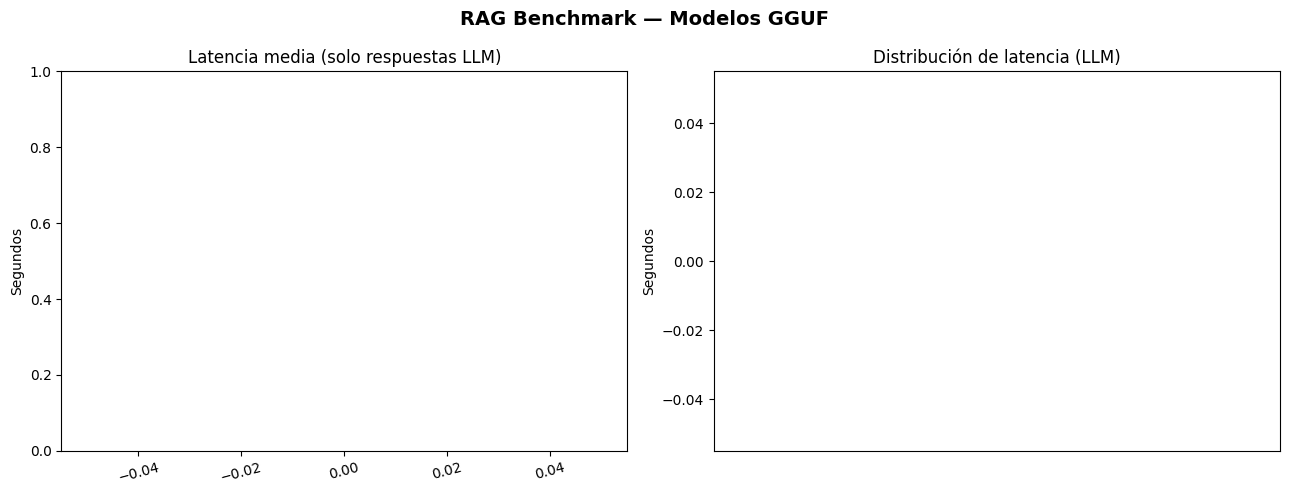

📁 Gráfica guardada en test/benchmark_gguf.png


In [35]:
import matplotlib.pyplot as plt

if df.empty:
    print("⚠️  No hay resultados para graficar.")
else:
    df_llm = df[df["fuente"] == "llm"].copy()
    modelos_presentes = df_llm["modelo"].unique()
    colores = {"qwen3-4b": "#2196F3", "gemma-4-e2b": "#4CAF50", "qwen3-1.7b": "#FF9800"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("RAG Benchmark — Modelos GGUF", fontsize=14, fontweight="bold")

    # ── Barras: latencia media por modelo ────────────────────────────────────
    ax1 = axes[0]
    modelos_ord = list(modelos_presentes)
    lat_medias  = [df_llm[df_llm["modelo"] == m]["latencia_s"].mean() for m in modelos_ord]
    bars = ax1.bar(
        modelos_ord, lat_medias,
        color=[colores.get(m, "#9E9E9E") for m in modelos_ord],
        edgecolor="white", linewidth=0.8
    )
    for bar, val in zip(bars, lat_medias):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{val:.2f}s", ha="center", va="bottom", fontsize=10
        )
    ax1.set_title("Latencia media (solo respuestas LLM)")
    ax1.set_ylabel("Segundos")
    ax1.set_ylim(0, max(lat_medias) * 1.3 + 0.5 if lat_medias else 1)
    ax1.tick_params(axis="x", rotation=15)

    # ── Caja: distribución de latencias ──────────────────────────────────────
    ax2 = axes[1]
    datos_box   = [df_llm[df_llm["modelo"] == m]["latencia_s"].values for m in modelos_ord]
    bp          = ax2.boxplot(datos_box, patch_artist=True, widths=0.5)
    for patch, m in zip(bp["boxes"], modelos_ord):
        patch.set_facecolor(colores.get(m, "#9E9E9E"))
        patch.set_alpha(0.7)
    ax2.set_xticks(range(1, len(modelos_ord) + 1))
    ax2.set_xticklabels(modelos_ord, rotation=15)
    ax2.set_title("Distribución de latencia (LLM)")
    ax2.set_ylabel("Segundos")

    plt.tight_layout()
    plt.savefig(ROOT / "test" / "benchmark_gguf.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("📁 Gráfica guardada en test/benchmark_gguf.png")

## 14 · Gráfica: fuente de respuesta por modelo (cache vs LLM)

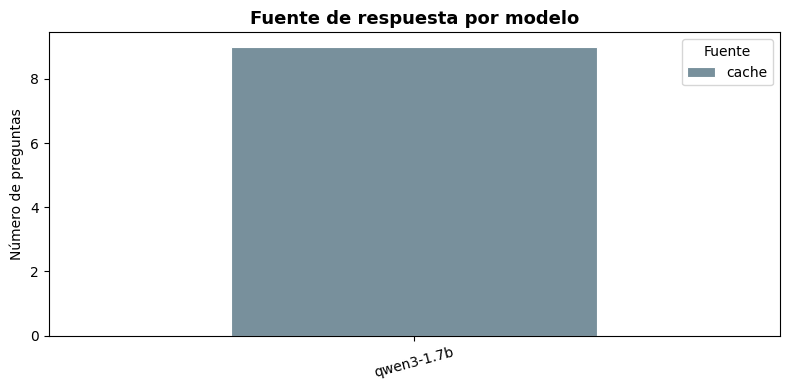

📁 Gráfica guardada en test/fuente_respuesta.png


In [36]:
if df.empty:
    print("⚠️  No hay resultados para graficar.")
else:
    conteo = df.groupby(["modelo", "fuente"]).size().unstack(fill_value=0)

    ax = conteo.plot(
        kind="bar", figsize=(8, 4),
        color={"cache": "#78909C", "llm": "#42A5F5"},
        edgecolor="white", linewidth=0.8
    )
    ax.set_title("Fuente de respuesta por modelo", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Número de preguntas")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Fuente")
    plt.tight_layout()
    plt.savefig(ROOT / "test" / "fuente_respuesta.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("📁 Gráfica guardada en test/fuente_respuesta.png")

## 15 · Chat interactivo con el modelo activo

Escribe tu pregunta en la variable `PREGUNTA` y vuelve a ejecutar la celda.

In [ ]:
# ✏️  Cambia aquí tu pregunta
PREGUNTA  = "¿Cuáles son los programas de ingeniería que ofrece la Universidad Libre?"
ETIQUETA  = "Visitante"
CONTEXTO  = "Persona en el hall de entrada de la universidad"

# ─────────────────────────────────────────────────
obj = GlobalObjectForContext(
    id_global = "chat-interactivo",
    etiqueta  = ETIQUETA,
    confianza = 0.85,
    contexto  = CONTEXTO,
    question  = PREGUNTA,
)

t0        = time.perf_counter()
resultado = responder(obj, secuencias)
latencia  = time.perf_counter() - t0

print(f"{'─'*60}")
print(f"Modelo   : {modelo_activo()}")
print(f"Pregunta : {PREGUNTA}")
print(f"Fuente   : {resultado['fuente']}")
print(f"Latencia : {latencia:.2f}s")
print(f"Movimiento: {resultado['movimiento']}")
print(f"{'─'*60}")
print(f"Respuesta:\n{resultado['respuesta']}")

────────────────────────────────────────────────────────────
Modelo   : qwen3-1.7b
Pregunta : ¿Cuáles son los programas de ingeniería que ofrece la Universidad Libre?
Fuente   : cache
Latencia : 0.08s
Movimiento: 1
────────────────────────────────────────────────────────────
Respuesta:
Programas desde pregrado hasta doctorado en Derecho, Ingeniería y más.


I0926 19:17:08.781230 9872910 chttp2_transport.cc:1369] ipv4:127.0.0.1:63596: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {http2_error:11, grpc_status:14}
E0926 19:17:08.781284 9872910 chttp2_transport.cc:1401] ipv4:127.0.0.1:63596: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 10000ms


: 

## 16 · Exportar resultados a CSV

In [ ]:
if not df.empty:
    csv_path = ROOT / "test" / "benchmark_resultados.csv"
    df.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"✅ Resultados exportados a: {csv_path}")
    print(f"   Filas: {len(df)}  |  Columnas: {list(df.columns)}")
else:
    print("⚠️  No hay resultados que exportar. Ejecuta primero el benchmark.")